In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('bank_advanced_dataset.csv')
print("Первые 10 строк данных:")
print(df.head(10))

print("\nКоличество клиентов по типам счетов:")
print(df['Account_Type'].value_counts())

print("\nСредние и медианные показатели (Balance, Loan_Amount, Credit_Score):")
metrics = ['Balance', 'Loan_Amount', 'Credit_Score']
print(df[metrics].agg(['mean', 'median']))

Первые 10 строк данных:
  Customer_ID Account_Type  Age  Gender Region    Income   Balance  \
0  CUST_00001     Business   68    Male   West  39600.61  14877.46   
1  CUST_00002         Loan   57    Male  South  71789.11  37092.29   
2  CUST_00003      Savings   24    Male  South  33268.30  25090.72   
3  CUST_00004     Business   49   Other   East  78412.74  24792.88   
4  CUST_00005     Business   65    Male   West  82644.14   1561.47   
5  CUST_00006         Loan   36   Other  North  73629.60  12842.44   
6  CUST_00007      Savings   23  Female  South  56856.16  19292.96   
7  CUST_00008      Savings   37   Other  South   -947.85  -8117.28   
8  CUST_00009     Business   44  Female  North  46304.38  29346.68   
9  CUST_00010     Checking   70   Other  North  85297.60  32803.68   

   Credit_Score  Loan_Amount Loan_Status  ...  Feature_31  Feature_32  \
0           809     27578.43    Rejected  ...      114.73      138.40   
1           693     13279.94    Rejected  ...       81.62  

In [3]:
# --- Задача 2: Работа со строками и списками

ids_long = [str(cid) for cid in df['Customer_ID'] if len(str(cid)) > 8] # [cite: 104]


upper_regions = [r.upper() for r in df['Region'].unique()] # [cite: 104]


mean_age_north = df[df['Region'] == 'North']['Age'].mean() # [cite: 105]
print(f"\nСредний возраст клиентов в регионе NORTH: {mean_age_north:.2f}")
print(f"\nСписок ID длиннее 8 символов:{len(ids_long)}")
print(f"\nСписок уникальных регионов в верхнем регистре:{upper_regions}")


Средний возраст клиентов в регионе NORTH: 48.76

Список ID длиннее 8 символов:10000

Список уникальных регионов в верхнем регистре:['WEST', 'SOUTH', 'EAST', 'NORTH']


In [4]:
# --- Задача 3: Фильтрация и генератор

premium_clients_gen = (
    (row['Customer_ID'], row['Credit_Score'], row['Balance'])
    for index, row in df.iterrows()
    if row['Credit_Score'] >= 750 and row['Balance'] >= 50000
)

print("\nПервые 15 премиум-клиентов из генератора:")
for _ in range(15):
    try:
        print(next(premium_clients_gen))
    except StopIteration:
        break


Первые 15 премиум-клиентов из генератора:
('CUST_00125', 783, 55527.93)
('CUST_00354', 764, 50870.57)
('CUST_00637', 782, 51218.79)
('CUST_00702', 790, 57937.45)
('CUST_00758', 806, 52148.64)
('CUST_01962', 805, 51742.13)
('CUST_02226', 837, 53057.33)
('CUST_02749', 778, 51835.39)
('CUST_03205', 840, 55713.16)
('CUST_03297', 788, 52132.74)
('CUST_03448', 795, 58410.9)
('CUST_03512', 841, 53870.09)
('CUST_03553', 764, 53129.25)
('CUST_03735', 813, 50149.6)
('CUST_04195', 759, 54399.08)


In [5]:
# --- Задача 4: Dict и подсчеты --- [cite: 111, 112]

approved_loans = df[df['Loan_Status'] == 'Approved']
region_approved_dict = approved_loans['Region'].value_counts().to_dict()

max_approved_region = max(region_approved_dict, key=region_approved_dict.get)
print(f"\nРегион с наибольшим числом одобренных кредитов: {max_approved_region}")


Регион с наибольшим числом одобренных кредитов: West


In [6]:
# --- Задача 5: Set и уникальные комбинации
unique_combos = set(zip(df['Region'], df['Account_Type']))
print(f"Количество уникальных комбинаций (Region + Account_Type): {len(unique_combos)}")

Количество уникальных комбинаций (Region + Account_Type): 16


In [7]:
# --- Задача 6: Lambda функции --- [cite: 119, 120]
# Формула: credit_efficiency = Balance / (Loan_Amount + 1)
df['credit_efficiency'] = df.apply(
    lambda x: x['Balance'] / (x['Loan_Amount'] + 1), axis=1
)

print("\nТоп-10 клиентов по кредитной эффективности:")
print(df.nlargest(10, 'credit_efficiency')[['Customer_ID', 'credit_efficiency']])


Топ-10 клиентов по кредитной эффективности:
     Customer_ID  credit_efficiency
3277  CUST_03278        8940.643653
2263  CUST_02264        1299.102280
9355  CUST_09356        1231.672486
3298  CUST_03299         947.321201
8817  CUST_08818         776.775523
1975  CUST_01976         688.593166
5842  CUST_05843         662.990703
7656  CUST_07657         560.136744
760   CUST_00761         553.446052
9104  CUST_09105         381.051580


In [8]:
# --- Задача 7: NumPy векторы
num_data = df[['Age', 'Income', 'Balance', 'Loan_Amount', 'Credit_Score']].values

# Статистика для credit_efficiency через NumPy
ce_array = df['credit_efficiency'].values
print(f"\nСтатистика эффективности (Mean): {np.mean(ce_array):.2f}")
print(f"Статистика эффективности (Median): {np.median(ce_array):.2f}")
print(f"Статистика эффективности (STD): {np.std(ce_array):.2f}")

# Индекс клиента с макс. эффективностью
max_eff_idx = np.argmax(ce_array)
print(f"Индекс клиента с максимальной эффективностью: {max_eff_idx}")


Статистика эффективности (Mean): 2.34
Статистика эффективности (Median): 1.14
Статистика эффективности (STD): 104.66
Индекс клиента с максимальной эффективностью: 3277


In [9]:
# --- Задача 8: Сводные таблицы
pivot_table = df.pivot_table(
    index='Region',
    columns='Account_Type',
    values='credit_efficiency',
    aggfunc='mean'
)

pivot_table.to_csv('student3_credit_efficiency.csv')
display(pivot_table)

Account_Type,Business,Checking,Loan,Savings
Region,,,,
East,3.156172,2.057280,2.466264,1.383631
North,-5.850350,1.614180,15.073391,2.004594
South,1.535420,2.110037,1.488271,2.341230
West,1.975928,2.099949,1.360552,2.517281


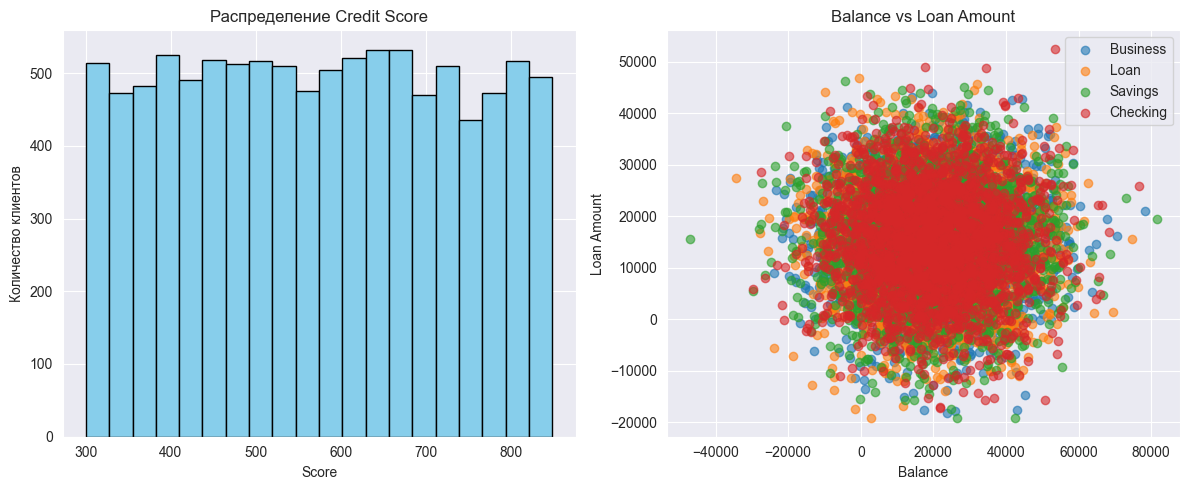

In [10]:
# --- Задача 9: Визуализация Matplotlib
plt.figure(figsize=(12, 5))

# Гистограмма Credit_Score
plt.subplot(1, 2, 1)
plt.hist(df['Credit_Score'], bins=20, color='skyblue', edgecolor='black')
plt.title('Распределение Credit Score')
plt.xlabel('Score')
plt.ylabel('Количество клиентов')
plt.grid(True)

# Scatter plot: Balance vs Loan_Amount
plt.subplot(1, 2, 2)
for acc_type in df['Account_Type'].unique():
    subset = df[df['Account_Type'] == acc_type]
    plt.scatter(subset['Balance'], subset['Loan_Amount'], label=acc_type, alpha=0.6)
plt.title('Balance vs Loan Amount')
plt.xlabel('Balance')
plt.ylabel('Loan Amount')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('student3_matplotlib_plots.png')
plt.show()

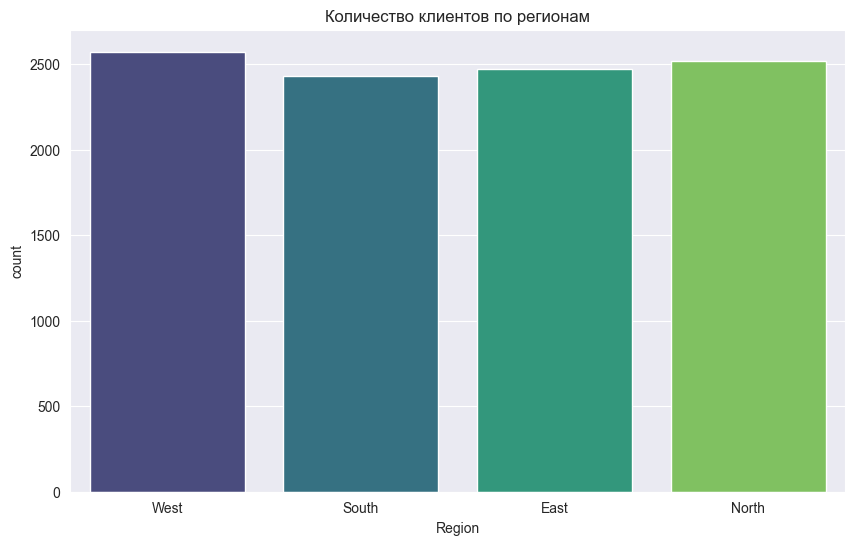

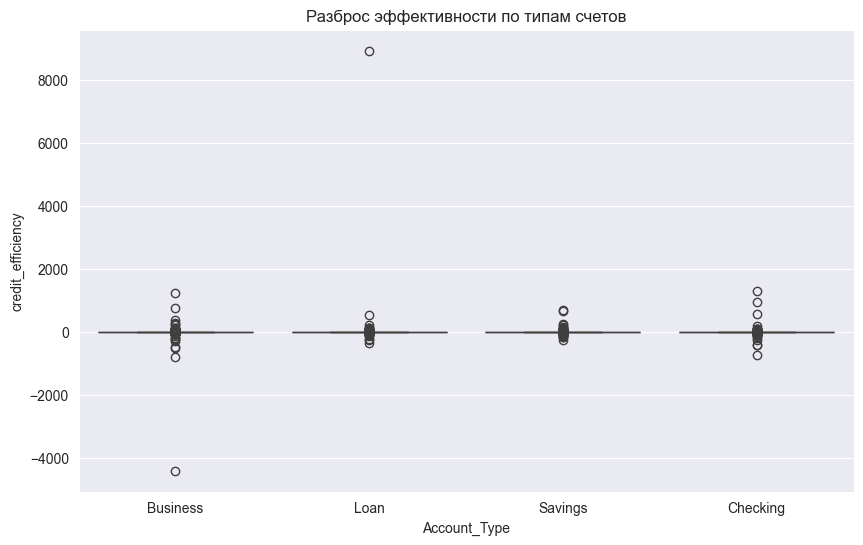

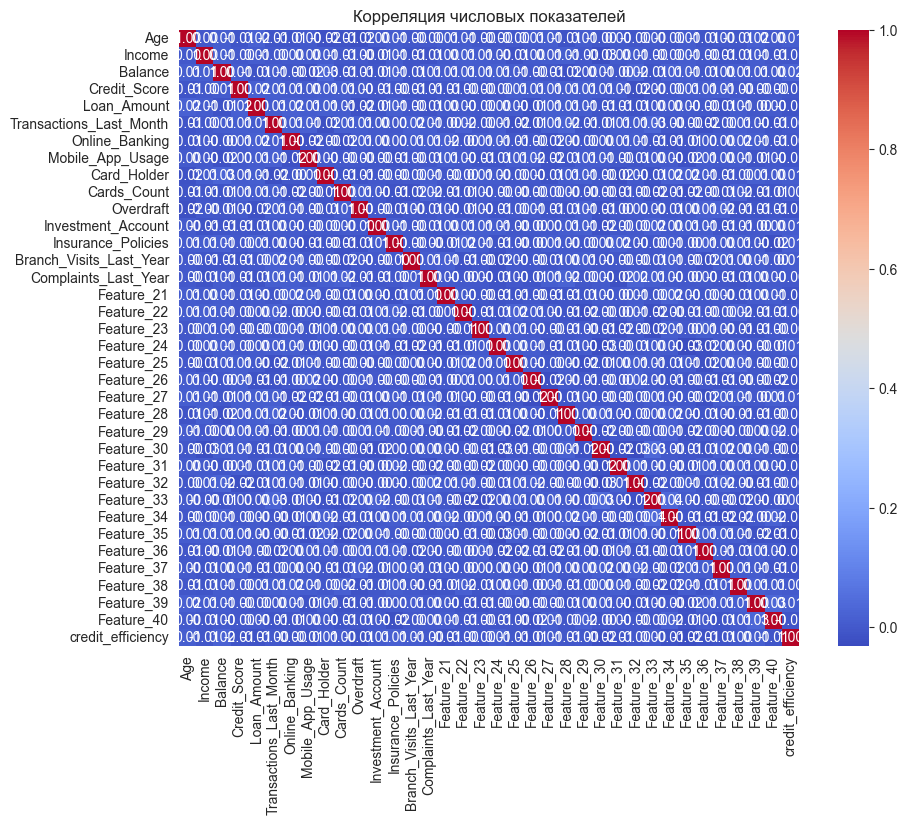

In [11]:
# --- Задача 10: Визуализация Seaborn
# Countplot по регионам
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Region',hue='Region', palette='viridis',legend=False)
plt.title('Количество клиентов по регионам')
plt.savefig('student3_region_count.png')
plt.show()

# Boxplot credit_efficiency по типам счетов
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Account_Type', y='credit_efficiency')
plt.title('Разброс эффективности по типам счетов')
plt.savefig('student3_efficiency_boxplot.png')
plt.show()

# Heatmap корреляции
plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Корреляция числовых показателей')
plt.savefig('student3_correlation_heatmap.png')
plt.show()